# NB10_StatAnalysis_AllGroups
HF project: `boods/FrMedQA-CrossLingual-v2-PPL-<qlora|bf16>-*`
Path: `/content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab-v2`


In [ ]:
# ⚙️ Stage 0 — Install dependencies (Colab)
import subprocess, sys, importlib

REQUIRED = {"unsloth":"unsloth","transformers":"transformers","peft":"peft",
            "bitsandbytes":"bitsandbytes","datasets":"datasets",
            "rouge_score":"rouge-score","nltk":"nltk","bert_score":"bert-score",
            "huggingface_hub":"huggingface-hub","tqdm":"tqdm",
            "sklearn":"scikit-learn","sacrebleu":"sacrebleu", "modelscope": "modelscope",
            "datasketch": "datasketch"}

missing_pkgs_to_install = []
for mod, pkg in REQUIRED.items():
    if importlib.util.find_spec(mod) is None:
        missing_pkgs_to_install.append(pkg)

if missing_pkgs_to_install:
    print(f"Attempting to install missing packages: {missing_pkgs_to_install}")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing_pkgs_to_install)
        print("Successfully installed missing packages. A kernel restart is recommended for full effect.")
    except subprocess.CalledProcessError as e:
        print(f"Error during installation of {missing_pkgs_to_install}: {e}. Please install manually.")
        raise
    except Exception as e:
        print(f"An unexpected error occurred during package installation: {e}")
        raise

try:
    import nltk
    nltk.download("punkt_tab", quiet=True)
    nltk.download("punkt", quiet=True)
except Exception:
    pass
print("✓ Stage 0 done")


In [ ]:
# ⚙️ Stage 0b — Drive mount, paths, secrets
import os, sys

def _on_colab():
    try:
        import google.colab; return True
    except Exception: return False

if _on_colab():
    from google.colab import drive
    drive.mount("/content/drive")

    def _secret(name, prompt):
        try:
            from google.colab import userdata
            v = userdata.get(name)
            if v: return v
        except Exception: pass
        import getpass
        return getpass.getpass(prompt)
    os.environ["HF_TOKEN"] = _secret("HF_TOKEN", "HF_TOKEN: ")
    _wb = _secret("WANDB_API_KEY", "WANDB_API_KEY (blank to skip): ")
    if _wb:
        os.environ["WANDB_API_KEY"] = _wb
    else:
        os.environ["WANDB_DISABLED"] = "true"

BASE_DIR = os.environ.get("FRMEDQA_BASE", "/content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab-v2")
REPO_DIR    = BASE_DIR
RESULTS_DIR = os.path.join(BASE_DIR, "RESULT")
EVALS_DIR   = os.path.join(BASE_DIR, "EVALS")
CACHE_DIR   = os.path.join(EVALS_DIR, "results_cache")
OUT_DIR     = os.path.join(BASE_DIR, "analysis_output")
FIG_DIR     = os.path.join(OUT_DIR, "figures")
for d in (RESULTS_DIR, EVALS_DIR, CACHE_DIR, OUT_DIR, FIG_DIR):
    os.makedirs(d, exist_ok=True)

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
os.environ["FRMEDQA_REPO"] = REPO_DIR
os.environ["FRMEDQA_BASE"] = BASE_DIR
os.environ["FRMEDQA_HF_USER"] = "boods"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

for v in ("HF_HOME", "HF_HUB_CACHE", "TRANSFORMERS_CACHE", "HUGGINGFACE_HUB_CACHE"):
    os.environ[v] = os.path.join(BASE_DIR, "hf_cache")

print(f"BASE_DIR: {BASE_DIR}")
print(f"CACHE_DIR: {CACHE_DIR}")


In [ ]:
os.environ["FRMEDQA_PROJECT_NAME"] = "FrMedQA-CrossLingual-v2-PPL"
if os.environ.get("FRMEDQA_SEED"):   # cluster multi-seed run: one HF namespace per seed
    os.environ["FRMEDQA_PROJECT_NAME"] += f"-s{os.environ['FRMEDQA_SEED']}"
print(f"HF project: {os.environ['FRMEDQA_PROJECT_NAME']}")


## 🔒 Three-way comparison restriction
Below only three groups are compared: **Qwen3-14B-vanilla**, **Perplexity-\***, **NoPPL-\***. Everything else is ignored.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# THREE-WAY COMPARISON RESTRICTION
# From here on we compare ONLY three model groups:
#   1. Vanilla reference    → Qwen3-14B-vanilla
#   2. Perplexity pipeline  → Perplexity-{DAPT,MCQA,ExtQA,AbsQA,Unified}
#   3. NoPPL pipeline       → NoPPL-{DAPT,MCQA,ExtQA,AbsQA,Unified}
# All other cached models are IGNORED in this analysis.
# ═══════════════════════════════════════════════════════════════════════════
VANILLA_REF        = "Qwen3-14B-vanilla"
REF                = VANILLA_REF
PERPLEXITY_MODELS  = ["Perplexity-DAPT","Perplexity-MCQA","Perplexity-ExtQA",
                      "Perplexity-AbsQA","Perplexity-Unified"]
NOPPL_MODELS       = ["NoPPL-DAPT","NoPPL-MCQA","NoPPL-ExtQA",
                      "NoPPL-AbsQA","NoPPL-Unified"]
# External baselines (NB5a): shown in tables / figures with the vanilla
# group. The statistical comparisons stay anchored on VANILLA_REF.
EXTRA_BASELINES    = ["Qwen3-8B", "Ministral-3-14B", "BioMistral-7B", "MedGemma-27B"]
VANILLA_MODELS     = [VANILLA_REF] + EXTRA_BASELINES
CANDIDATES         = PERPLEXITY_MODELS + NOPPL_MODELS
ALL_KEEP           = VANILLA_MODELS + CANDIDATES

def model_group(name):
    if name is None: return "?"
    if name == VANILLA_REF or name in EXTRA_BASELINES:              return "vanilla"
    if name.startswith("Perplexity-"):   return "perplexity"
    if name.startswith("NoPPL-"):        return "noppl"
    return "excluded"

GROUP_STYLE = {
    "vanilla":    dict(color="white",     hatch="//",  edgecolor="black"),
    "perplexity": dict(color="lightgray", hatch="",    edgecolor="black"),
    "noppl":      dict(color="0.55",      hatch="xx",  edgecolor="black"),
}

print(f"Three-way comparison restricted to {len(ALL_KEEP)} models:")
for m in ALL_KEEP:
    print(f"  [{model_group(m):10s}] {m}")


In [ ]:
# 🧹 Figures folder — cleared once by NB7 at the start of the chain.
# Keep False so this notebook does not delete upstream figures.
import os, glob, shutil
RESET_FIGURES = False
if RESET_FIGURES and os.path.isdir(FIG_DIR):
    for _f in glob.glob(os.path.join(FIG_DIR, "*")):
        (shutil.rmtree if os.path.isdir(_f) else os.remove)(_f)
    print(f"  ✓ cleared {FIG_DIR}")
os.makedirs(FIG_DIR, exist_ok=True)
print(f"  figures → {FIG_DIR}  (RESET_FIGURES={RESET_FIGURES})")


In [ ]:

# ─── Three-group model classification ─────────────────────────────────────
def model_group(name):
    if name is None: return "?"
    if isinstance(name, str) and name.startswith("Perplexity-"): return "perplexity"
    if isinstance(name, str) and name.startswith("NoPPL-"):      return "noppl"
    return "vanilla"


# Hatch/marker patterns for black-and-white plots (no colour reliance)
GROUP_HATCH  = {"vanilla": "",   "perplexity": "////", "noppl": "xxxx"}
GROUP_MARKER = {"vanilla": "o",  "perplexity": "s",    "noppl": "^"}


# 📊 NB10 — Statistical Analysis (paper-style, black-on-white)
**EnToFrMedicaLLM · consumes NB9 multi-judge outputs · no inference, no judging**

Reproduces the inferential apparatus of the Phase-1 paper for the **4-judge**
re-evaluation:

* **Pointwise (Judges 1 & 2 + consensus)** — per-`(shot)` **item-level paired
  t-tests** of every Perplexity-* and NoPPL-* variant against `Qwen3-14B-vanilla` on the AbsQA
  composite, with standardized effect size $d_z$, 95 % CIs, Benjamini–Hochberg
  FDR control, and TOST equivalence at $\pm0.2$ SD. Reported *separately for each
  pointwise judge and for their consensus*.
* **Pairwise (Judges 3 & 4)** — win/tie/loss, win-rate, net preference, exact
  binomial **sign tests** (BH-corrected), position-consistency, and inter-referee
  **Cohen's $\kappa$**.
* **Rank analysis** — Friedman test + Nemenyi **critical-difference diagrams**
  across all systems on the consensus AbsQA composite, per shot.

Inputs (produced by NB9): `EVALS/llm_judge_scores.json`,
`EVALS/pairwise_judge_results.json`, and the caches in `EVALS/results_cache`
(only for item-id alignment). **All figures are grayscale, white background.**


## ⚙️ Stage 0 — Imports + strict black-on-white plotting style

In [1]:
import subprocess, sys, importlib
for mod, pkg in {"numpy":"numpy","pandas":"pandas","scipy":"scipy",
                 "statsmodels":"statsmodels","matplotlib":"matplotlib"}.items():
    try: importlib.import_module(mod)
    except ImportError:
        subprocess.check_call([sys.executable,"-m","pip","install","-q",pkg])

import os, json, itertools, datetime
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import binomtest
from statsmodels.stats.multitest import multipletests
import matplotlib as mpl
import matplotlib.pyplot as plt

# ── Strict monochrome, publication style ─────────────────────────────────
mpl.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "savefig.facecolor": "white", "savefig.dpi": 300, "figure.dpi": 110,
    "font.family": "serif", "font.size": 11,
    "axes.edgecolor": "black", "axes.labelcolor": "black",
    "axes.titlecolor": "black", "text.color": "black",
    "xtick.color": "black", "ytick.color": "black",
    "axes.grid": False, "axes.spines.top": False, "axes.spines.right": False,
    "lines.color": "black", "patch.edgecolor": "black", "patch.facecolor": "white",
    "legend.frameon": True, "legend.edgecolor": "black",
    "image.cmap": "Greys",
})
# Grayscale fills to distinguish categories without color
GREY = {"win": "black", "tie": "0.65", "loss": "white",
        "enmed": "0.15", "ref": "white", "control": "0.6"}
HATCH = {"win": "", "tie": "///", "loss": "xx"}

def now_ts():
    return datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

def stars(p):
    if p is None or (isinstance(p, float) and np.isnan(p)): return ""
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""

print("✓ imports + monochrome style ready")


✓ imports + monochrome style ready


## 📁 Stage 1 — Load NB9 judge outputs + build paired item vectors

In [2]:
# Stage 1 — paths, load judge JSONs, align per-item scores to item ids
BASE_DIR = os.environ.get("FRMEDQA_BASE", "/content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab-v2")
EVALS_DIR      = os.path.join(BASE_DIR, "EVALS")
EVAL_CACHE_DIR = os.path.join(EVALS_DIR, "results_cache")
RESULTS_DIR    = os.path.join(BASE_DIR, "RESULT")
FIG_DIR        = os.path.join(RESULTS_DIR, "figures_stats_paper")
OUT_DIR        = os.path.join(RESULTS_DIR, "stats_paper")

if "google.colab" in sys.modules and not os.path.exists(BASE_DIR):
    from google.colab import drive; drive.mount("/content/drive")
os.makedirs(FIG_DIR, exist_ok=True); os.makedirs(OUT_DIR, exist_ok=True)

LLM_JUDGE_OUT = os.path.join(EVALS_DIR, "llm_judge_scores.json")
PAIRWISE_OUT  = os.path.join(EVALS_DIR, "pairwise_judge_results.json")
assert os.path.exists(LLM_JUDGE_OUT), f"missing {LLM_JUDGE_OUT} — run NB9 first."

DELTA_TOST = 0.2                     # ±0.2 SD equivalence margin (paper's ∆)
AXES = ["factual","complete","relevance","safety","composite"]

judge_data = json.load(open(LLM_JUDGE_OUT, encoding="utf-8"))
ABS_JUDGES = sorted(judge_data.keys())          # e.g. ['gemma4_12b_qat','gptoss_20b_f16']
print("Pointwise judges:", ABS_JUDGES)

def _cache_ids(fname):
    """Row ids for a cache file, positional fallback."""
    p = os.path.join(EVAL_CACHE_DIR, fname)
    if not os.path.exists(p): return None
    try:
        rows = json.load(open(p, encoding="utf-8")).get("rows", [])
        return [str(r.get("id", i)) for i, r in enumerate(rows)]
    except Exception:
        return None

# item_axis[(judge, model, shot, axis)] -> {item_id: score}
item_axis = {}
for jname, files in judge_data.items():
    for fname, d in files.items():
        if d.get("model") not in ALL_KEEP: continue
        scored = d.get("scores") or []
        if not scored: continue
        ids = _cache_ids(fname) or [str(i) for i in range(len(scored))]
        for i, s in enumerate(scored):
            if not s or i >= len(ids): continue
            for a in AXES:
                if s.get(a) is not None:
                    item_axis.setdefault((jname, d["model"], d["n_shot"], a), {})[ids[i]] = float(s[a])

MODELS = sorted({k[1] for k in item_axis})
SHOTS  = sorted({k[2] for k in item_axis})
print("Models :", MODELS)
print("candidates:", CANDIDATES)
print("Shots  :", SHOTS)

# Consensus per item = mean over pointwise judges, per axis
def consensus_map(model, shot, axis):
    acc = {}
    for j in ABS_JUDGES:
        for rid, v in item_axis.get((j, model, shot, axis), {}).items():
            acc.setdefault(rid, []).append(v)
    return {rid: float(np.mean(vs)) for rid, vs in acc.items()}

def paired(model, shot, axis, source):
    """Return aligned (enmed_vec, ref_vec) over common items. source: judge name or 'consensus'."""
    if source == "consensus":
        de, dv = consensus_map(model, shot, axis), consensus_map(VANILLA_REF, shot, axis)
    else:
        de = item_axis.get((source, model, shot, axis), {})
        dv = item_axis.get((source, VANILLA_REF, shot, axis), {})
    common = sorted(set(de) & set(dv))
    return np.array([de[r] for r in common]), np.array([dv[r] for r in common])

print("✓ per-item paired vectors ready "
      f"({len(item_axis)} judge×model×shot×axis cells)")

Mounted at /content/drive
Pointwise judges: ['gemma4_31b', 'gpt54_nano']
Models : ['EnMed-AbsQA', 'EnMed-DAPT', 'EnMed-ExtQA', 'EnMed-MCQA', 'EnMed-Unified', 'Mistral-7B-Instruct-v0.3', 'Qwen3-14B-vanilla', 'Qwen3-8B']
EnMed  : ['EnMed-AbsQA', 'EnMed-DAPT', 'EnMed-ExtQA', 'EnMed-MCQA', 'EnMed-Unified']
Shots  : [0, 3, 5]
✓ per-item paired vectors ready (240 judge×model×shot×axis cells)


## 🎯 Stage 2 — Pointwise item-level paired **t-tests, per shot, per judge**

For every Perplexity-* and NoPPL-* variant × shot, against the reference on the AbsQA composite:
paired $t$, $p$, standardized $d_z=\bar d/s$, and its 95 % CI. Computed
**separately for Judge 1, Judge 2, and their consensus**, then BH-corrected
within each source's family of cells.

In [3]:
# Stage 2 — pointwise paired t-tests (composite), per shot, per judge + consensus
def dz_ci(diff, conf=0.95):
    """dz and CI via SE = sqrt(1/N + dz^2/(2N)) (paired standardized effect)."""
    N = len(diff)
    if N < 2: return np.nan, (np.nan, np.nan)
    s = diff.std(ddof=1)
    dz = diff.mean() / s if s > 0 else 0.0
    se = np.sqrt(1.0/N + dz**2/(2*N))
    z = stats.norm.ppf(0.5 + conf/2)
    return dz, (dz - z*se, dz + z*se)

SOURCES = ABS_JUDGES + ["consensus"]
rows = []
for src in SOURCES:
    for m in CANDIDATES:
        for s in SHOTS:
            a, b = paired(m, s, "composite", src)
            if len(a) < 5: continue
            diff = a - b
            t, p = stats.ttest_rel(a, b)
            dz, (lo, hi) = dz_ci(diff)
            rows.append({"source": src, "model": m, "n_shot": s, "N": len(a),
                         "mean_cand": a.mean(), "mean_ref": b.mean(),
                         "delta": diff.mean(), "t": t, "df": len(a)-1,
                         "p": p, "dz": dz, "dz_lo": lo, "dz_hi": hi})
df_pt = pd.DataFrame(rows)

# BH-FDR within each source across its cells
df_pt["p_fdr"] = np.nan; df_pt["sig_fdr"] = False
for src, idx in df_pt.groupby("source").groups.items():
    sub = df_pt.loc[idx]
    rej, p_bh, _, _ = multipletests(sub["p"], alpha=0.05, method="fdr_bh")
    df_pt.loc[idx, "p_fdr"] = p_bh
    df_pt.loc[idx, "sig_fdr"] = rej
df_pt["sig_raw"] = df_pt["p"] < 0.05
df_pt.to_csv(os.path.join(OUT_DIR, "pointwise_ttests_by_shot.csv"), index=False)

# Pretty per-shot table for the consensus source (paper's Table-4 shape)
def stars_row(r):
    return f"{r['dz']:+.3f}{stars(r['p'])}"
for src in SOURCES:
    sub = df_pt[df_pt["source"] == src]
    if sub.empty: continue
    piv = sub.pivot(index="model", columns="n_shot", values="dz").round(3)
    star = sub.assign(cell=sub.apply(stars_row, axis=1)) \
              .pivot(index="model", columns="n_shot", values="cell")
    print(f"\n══ Pointwise composite dz vs reference — source: {src} "
          f"(★ raw p<.05/.01/.001) ══")
    print(star.to_string())
print("\n✓ pointwise t-tests → pointwise_ttests_by_shot.csv")


══ Pointwise composite dz vs reference — source: gemma4_31b (★ raw p<.05/.01/.001) ══
n_shot                 0       3       5
model                                   
EnMed-AbsQA    -0.285***  -0.112  -0.112
EnMed-DAPT        -0.050  +0.031  -0.043
EnMed-ExtQA       -0.047  +0.023  -0.125
EnMed-MCQA        -0.037  -0.033  +0.065
EnMed-Unified     -0.035  +0.075  +0.057

══ Pointwise composite dz vs reference — source: gpt54_nano (★ raw p<.05/.01/.001) ══
n_shot               0        3       5
model                                  
EnMed-AbsQA    -0.137*  -0.144*  -0.110
EnMed-DAPT      +0.064   +0.059  +0.059
EnMed-ExtQA     +0.032   +0.058  -0.084
EnMed-MCQA      +0.029   +0.018  +0.050
EnMed-Unified   +0.097   +0.054  +0.026

══ Pointwise composite dz vs reference — source: consensus (★ raw p<.05/.01/.001) ══
n_shot                 0        3        5
model                                     
EnMed-AbsQA    -0.244***  -0.146*  -0.126*
EnMed-DAPT        +0.012   +0.054   +0.017
E

## 📏 Stage 3 — TOST equivalence ($\pm0.2$ SD) on the consensus composite

Two one-sided tests: a cell is declared *equivalent* to the reference when the
90 % CI for $d_z$ lies entirely inside $(-0.2,+0.2)$. This is the correct form
for "no worse than the reference" claims (a non-significant $p$ alone is not).

In [4]:
# Stage 3 — TOST equivalence on consensus composite
def tost(diff, delta=DELTA_TOST):
    N = len(diff)
    if N < 3: return None
    s = diff.std(ddof=1); dz = diff.mean()/s if s > 0 else 0.0
    se = np.sqrt(1.0/N + dz**2/(2*N))
    # 90% CI for dz
    z = stats.norm.ppf(0.95)
    lo, hi = dz - z*se, dz + z*se
    equivalent = (lo > -delta) and (hi < delta)
    # two one-sided p-values
    p_lower = stats.norm.sf((dz - (-delta)) / se)   # H0: dz <= -delta
    p_upper = stats.norm.cdf((dz - delta) / se)     # H0: dz >= +delta
    return {"dz": dz, "lo90": lo, "hi90": hi,
            "p_tost": max(p_lower, p_upper), "equivalent": equivalent}

tost_rows = []
for m in CANDIDATES:
    for s in SHOTS:
        a, b = paired(m, s, "composite", "consensus")
        if len(a) < 3: continue
        r = tost(a - b)
        if r: tost_rows.append({"model": m, "n_shot": s, "N": len(a), **r})
df_tost = pd.DataFrame(tost_rows)
df_tost.to_csv(os.path.join(OUT_DIR, "tost_equivalence.csv"), index=False)
print("══ TOST equivalence vs reference (consensus composite, ±0.2 SD) ══")
print(df_tost.round(3).to_string(index=False))
n_eq = int(df_tost["equivalent"].sum())
print(f"\n{n_eq}/{len(df_tost)} cells statistically equivalent to the reference.")

══ TOST equivalence vs reference (consensus composite, ±0.2 SD) ══
        model  n_shot   N     dz   lo90   hi90  p_tost  equivalent
  EnMed-AbsQA       0 248 -0.244 -0.350 -0.138   0.751       False
  EnMed-AbsQA       3 248 -0.146 -0.251 -0.041   0.199       False
  EnMed-AbsQA       5 248 -0.126 -0.231 -0.021   0.123       False
   EnMed-DAPT       0 248  0.012 -0.092  0.116   0.002        True
   EnMed-DAPT       3 248  0.054 -0.051  0.158   0.011        True
   EnMed-DAPT       5 248  0.017 -0.087  0.122   0.002        True
  EnMed-ExtQA       0 248 -0.011 -0.115  0.094   0.001        True
  EnMed-ExtQA       3 248  0.047 -0.058  0.151   0.008        True
  EnMed-ExtQA       5 248 -0.122 -0.227 -0.017   0.111       False
   EnMed-MCQA       0 248 -0.002 -0.107  0.102   0.001        True
   EnMed-MCQA       3 248 -0.005 -0.110  0.099   0.001        True
   EnMed-MCQA       5 248  0.061 -0.044  0.166   0.014        True
EnMed-Unified       0 248  0.033 -0.071  0.137   0.004        

## 🖼️ Stage 4 — Pointwise figures (black-on-white)

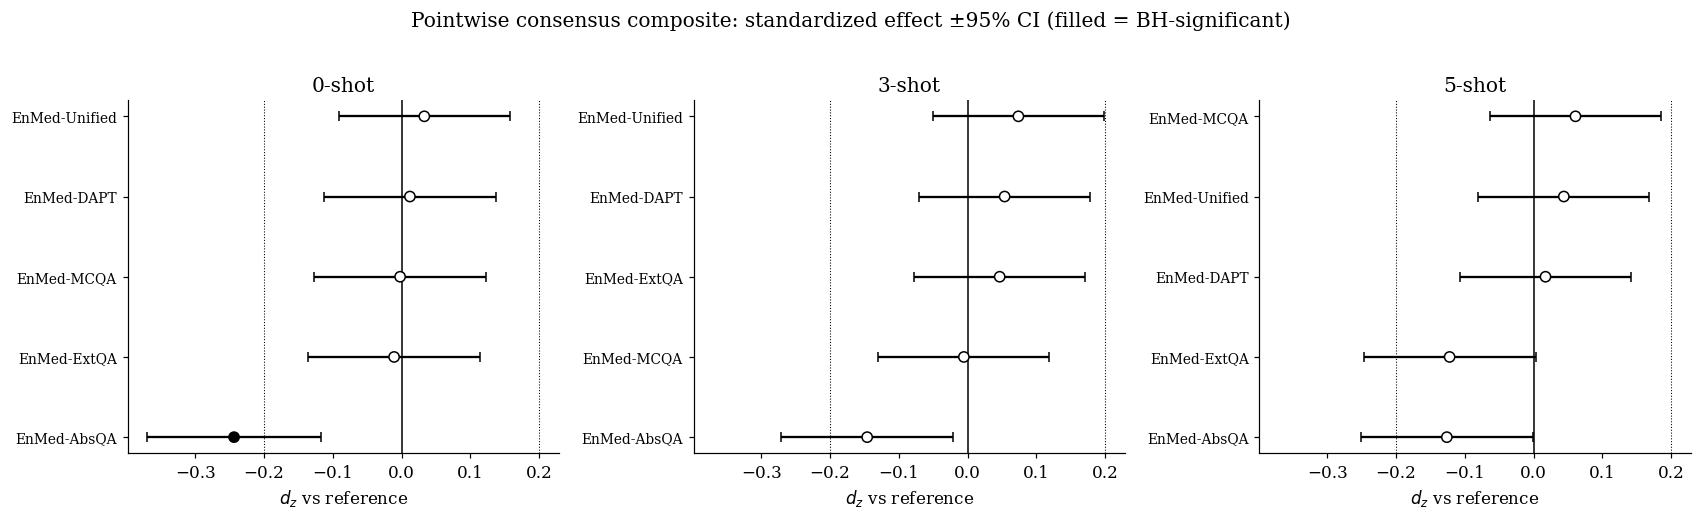

✓ /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/RESULT/figures_stats_paper/fig_pointwise_dz_forest.png


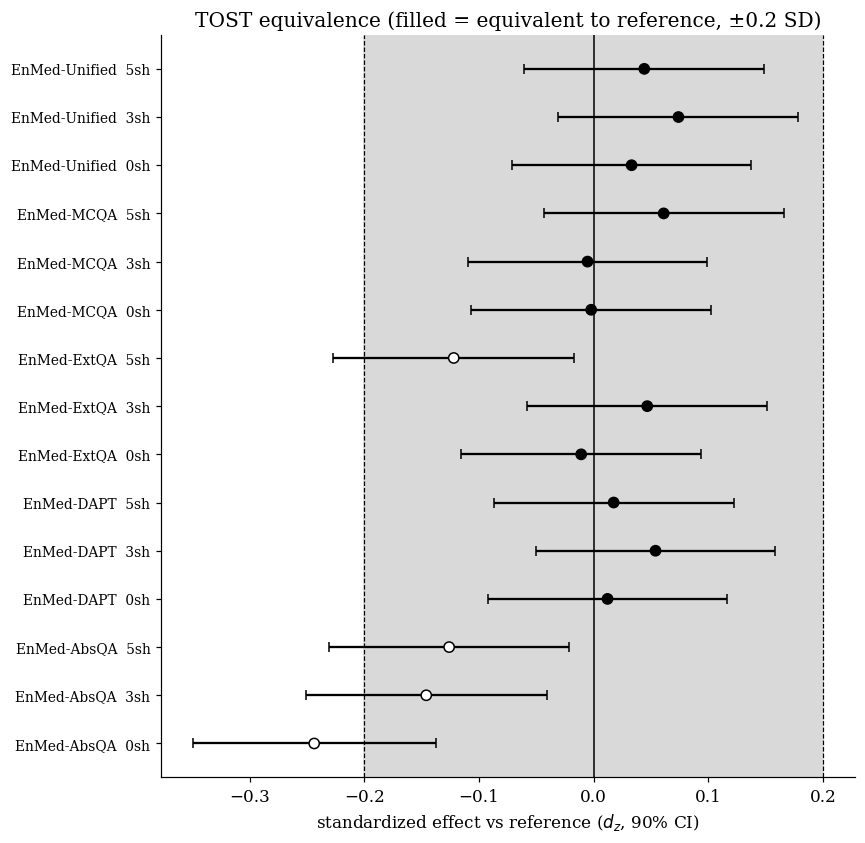

✓ /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/RESULT/figures_stats_paper/fig_tost_equivalence.png


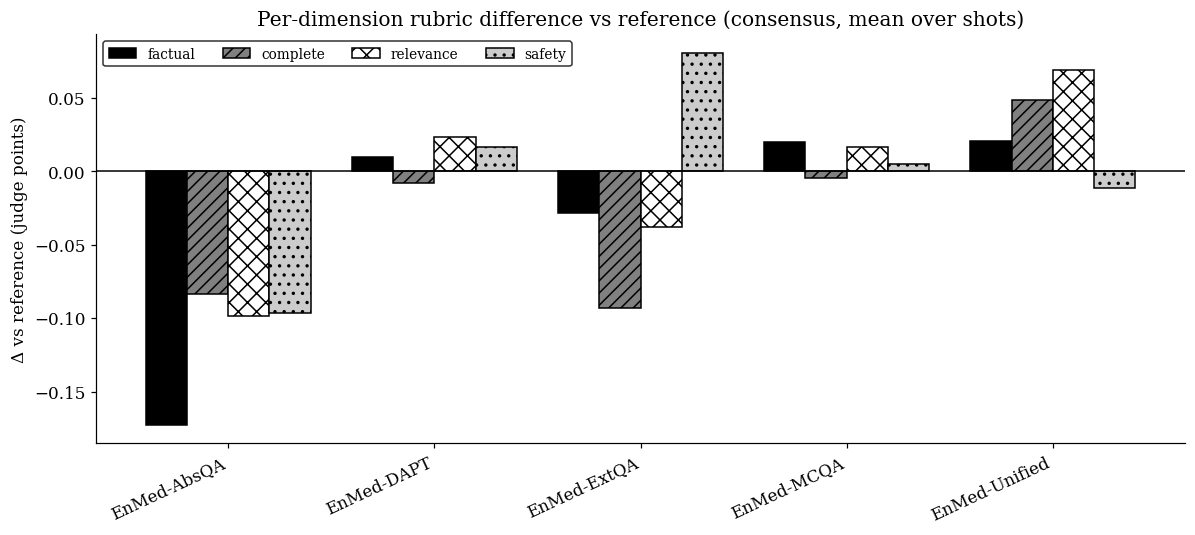

✓ /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/RESULT/figures_stats_paper/fig_rubric_dimensions.png


In [5]:
# Stage 4 — pointwise figures: (a) dz forest per shot per source, (b) TOST, (c) rubric
# (a) Forest of dz ± 95% CI, one panel per shot, consensus source
sub = df_pt[df_pt["source"] == "consensus"]
if not sub.empty:
    fig, axes = plt.subplots(1, len(SHOTS), figsize=(5.2*len(SHOTS), 4.6),
                             sharex=True)
    axes = np.atleast_1d(axes)
    for ax, s in zip(axes, SHOTS):
        cell = sub[sub["n_shot"] == s].sort_values("dz")
        y = np.arange(len(cell))
        ax.errorbar(cell["dz"], y,
                    xerr=[cell["dz"]-cell["dz_lo"], cell["dz_hi"]-cell["dz"]],
                    fmt="none", ecolor="black", capsize=3)
        mfc = ["black" if sig else "white" for sig in cell["sig_fdr"]]
        ax.scatter(cell["dz"], y, s=45, facecolors=mfc, edgecolors="black", zorder=3)
        ax.axvline(0, color="black", lw=1)
        ax.axvline(-0.2, color="black", lw=0.7, ls=":")
        ax.axvline(0.2, color="black", lw=0.7, ls=":")
        ax.set_yticks(y); ax.set_yticklabels(cell["model"], fontsize=9)
        ax.set_title(f"{s}-shot"); ax.set_xlabel(r"$d_z$ vs reference")
    fig.suptitle("Pointwise consensus composite: standardized effect ±95% CI "
                 "(filled = BH-significant)", y=1.02)
    plt.tight_layout()
    out = os.path.join(FIG_DIR, "fig_pointwise_dz_forest.png")
    plt.savefig(out, bbox_inches="tight"); plt.show(); print("✓", out)

# (b) TOST equivalence plot (paper Fig.1 style), 90% CI, filled = equivalent
if not df_tost.empty:
    dft = df_tost.copy()
    dft["label"] = dft["model"] + "  " + dft["n_shot"].astype(str) + "sh"
    dft = dft.sort_values(["model","n_shot"])
    y = np.arange(len(dft))
    fig, ax = plt.subplots(figsize=(8, 0.42*len(dft)+1.5))
    ax.axvspan(-0.2, 0.2, color="0.85", zorder=0)
    ax.errorbar(dft["dz"], y,
                xerr=[dft["dz"]-dft["lo90"], dft["hi90"]-dft["dz"]],
                fmt="none", ecolor="black", capsize=3, zorder=2)
    mfc = ["black" if e else "white" for e in dft["equivalent"]]
    ax.scatter(dft["dz"], y, s=45, facecolors=mfc, edgecolors="black", zorder=3)
    ax.axvline(0, color="black", lw=1)
    ax.axvline(-0.2, color="black", lw=0.8, ls="--")
    ax.axvline(0.2, color="black", lw=0.8, ls="--")
    ax.set_yticks(y); ax.set_yticklabels(dft["label"], fontsize=9)
    ax.set_xlabel(r"standardized effect vs reference ($d_z$, 90% CI)")
    ax.set_title("TOST equivalence (filled = equivalent to reference, ±0.2 SD)")
    plt.tight_layout()
    out = os.path.join(FIG_DIR, "fig_tost_equivalence.png")
    plt.savefig(out, bbox_inches="tight"); plt.show(); print("✓", out)

# (c) Per-dimension rubric drop vs reference (consensus), grouped bars, hatched
dim_rows = []
for m in CANDIDATES:
    for a in ["factual","complete","relevance","safety"]:
        vals = []
        for s in SHOTS:
            xe, xr = paired(m, s, a, "consensus")
            if len(xe): vals.append(xe.mean() - xr.mean())
        if vals: dim_rows.append({"model": m, "axis": a, "delta": np.mean(vals)})
df_dim = pd.DataFrame(dim_rows)
if not df_dim.empty:
    piv = df_dim.pivot(index="model", columns="axis", values="delta") \
                .reindex(columns=["factual","complete","relevance","safety"])
    fig, ax = plt.subplots(figsize=(11, 5))
    x = np.arange(len(piv)); w = 0.2
    fills  = ["black", "0.5", "white", "0.8"]
    hatches = ["", "///", "xx", ".."]
    for i, a in enumerate(piv.columns):
        ax.bar(x + (i-1.5)*w, piv[a], w, label=a, color=fills[i],
               edgecolor="black", hatch=hatches[i])
    ax.axhline(0, color="black", lw=1)
    ax.set_xticks(x); ax.set_xticklabels(piv.index, rotation=25, ha="right")
    ax.set_ylabel("Δ vs reference (judge points)")
    ax.set_title("Per-dimension rubric difference vs reference (consensus, mean over shots)")
    ax.legend(ncol=4, fontsize=9)
    plt.tight_layout()
    out = os.path.join(FIG_DIR, "fig_rubric_dimensions.png")
    plt.savefig(out, bbox_inches="tight"); plt.show(); print("✓", out)


## ⚔️ Stage 5 — Pairwise referees: deep statistical analysis

For each referee and pooled: win/tie/loss, win-rate (excl. ties), **net
preference** (win%−loss%), exact **binomial sign test** vs the 50 % null,
BH-FDR across cells, position-consistency, and inter-referee **Cohen's $\kappa$**
on shared decisive verdicts.

In [6]:
# Stage 5 — pairwise referee statistics (schema: challenger_model / opponent_model / axis)
pair_data = json.load(open(PAIRWISE_OUT, encoding="utf-8")) if os.path.exists(PAIRWISE_OUT) else {}
REFEREES = sorted(pair_data.keys())
print("Pairwise referees:", REFEREES)

pr_rows = []
for jn, duels in pair_data.items():
    for key, d in duels.items():
        challenger = d.get("challenger_model")   # records without it are from an older run
        opponent   = d.get("opponent_model") or VANILLA_REF
        axis       = d.get("axis", "?")
        if challenger is None or challenger not in ALL_KEEP: continue
        n_dec = d["wins"] + d["losses"]; n_all = max(1, d["n"])
        pr_rows.append({"referee": jn, "axis": axis,
                        "challenger": challenger, "opponent": opponent,
                        "n_shot": d["n_shot"], "n": d["n"],
                        "wins": d["wins"], "losses": d["losses"], "ties": d["ties"],
                        "win_rate": d["wins"]/n_dec if n_dec else np.nan,
                        "net_pref": (d["wins"]-d["losses"])/n_all,
                        "pos_consistency": d.get("position_consistency", np.nan),
                        "p_sign": binomtest(d["wins"], n_dec, 0.5).pvalue if n_dec else np.nan})
df_pair = pd.DataFrame(pr_rows)
if not df_pair.empty:
    ok = df_pair["p_sign"].notna()
    df_pair["p_fdr"] = np.nan; df_pair["sig_fdr"] = False
    rej, p_bh, _, _ = multipletests(df_pair.loc[ok, "p_sign"], alpha=0.05, method="fdr_bh")
    df_pair.loc[ok, "p_fdr"] = p_bh; df_pair.loc[ok, "sig_fdr"] = rej
    df_pair = df_pair.sort_values(["axis","referee","challenger","n_shot"])
    df_pair.to_csv(os.path.join(OUT_DIR, "pairwise_referee_stats.csv"), index=False)
    print("\n══ Per-referee win-rates + sign tests (per axis) ══")
    print(df_pair.round(3).to_string(index=False))

    # Pooled over referees — grouped by axis + challenger + shot
    pool = df_pair.groupby(["axis","challenger","opponent","n_shot"]).agg(
        wins=("wins","sum"), losses=("losses","sum"), ties=("ties","sum")).reset_index()
    pool["n_dec"] = pool["wins"] + pool["losses"]
    pool["win_rate"] = pool["wins"]/pool["n_dec"].replace(0, np.nan)
    pool["net_pref"] = (pool["wins"]-pool["losses"]) / \
        (pool["wins"]+pool["losses"]+pool["ties"]).replace(0, np.nan)
    pool["p_sign"] = [binomtest(int(w), int(n), 0.5).pvalue if n else np.nan
                      for w, n in zip(pool["wins"], pool["n_dec"])]
    okp = pool["p_sign"].notna()
    pool["p_fdr"] = np.nan; pool["sig_fdr"] = False
    rej, p_bh, _, _ = multipletests(pool.loc[okp, "p_sign"], alpha=0.05, method="fdr_bh")
    pool.loc[okp, "p_fdr"] = p_bh; pool.loc[okp, "sig_fdr"] = rej
    pool.to_csv(os.path.join(OUT_DIR, "pairwise_pooled.csv"), index=False)
    print("\n══ Pooled over referees + sign test (BH-FDR, per axis) ══")
    print(pool.round(3).to_string(index=False))

    # Compact per-axis summary
    print("\n══ Per-axis headline ══")
    for axis_name in sorted(pool["axis"].unique()):
        sub = pool[pool["axis"] == axis_name]
        wins   = int(sub["wins"].sum())
        losses = int(sub["losses"].sum())
        ties   = int(sub["ties"].sum())
        total  = wins + losses + ties
        if total:
            print(f"  {axis_name:22s}  wins={wins:4d}  losses={losses:4d}  ties={ties:4d}  "
                  f"win_rate={wins/(wins+losses+1e-9):.1%}")
else:
    print("No pairwise data found. Run NB9 first, then re-execute this cell.")
    pool = pd.DataFrame()


Pairwise referees: ['gemini31_flashlite', 'ministral14b']

══ Per-referee win-rates + sign tests ══
           referee   enmed_model  n_shot   n  wins  losses  ties  win_rate  net_pref  pos_consistency  p_sign  p_fdr  sig_fdr
gemini31_flashlite   EnMed-AbsQA       0 248    24      58   166     0.293    -0.137            0.746   0.000  0.007     True
gemini31_flashlite   EnMed-AbsQA       3 248    26      40   182     0.394    -0.056            0.710   0.109  0.233    False
gemini31_flashlite   EnMed-AbsQA       5 248    29      44   175     0.397    -0.060            0.754   0.101  0.232    False
gemini31_flashlite    EnMed-DAPT       0 248     8       8   232     0.500     0.000            0.875   1.000  1.000    False
gemini31_flashlite    EnMed-DAPT       3 248    12      10   226     0.545     0.008            0.903   0.832  0.981    False
gemini31_flashlite    EnMed-DAPT       5 248    10       9   229     0.526     0.004            0.915   1.000  1.000    False
gemini31_flashlite

## 🖼️ Stage 6 — Pairwise figures (black-on-white)

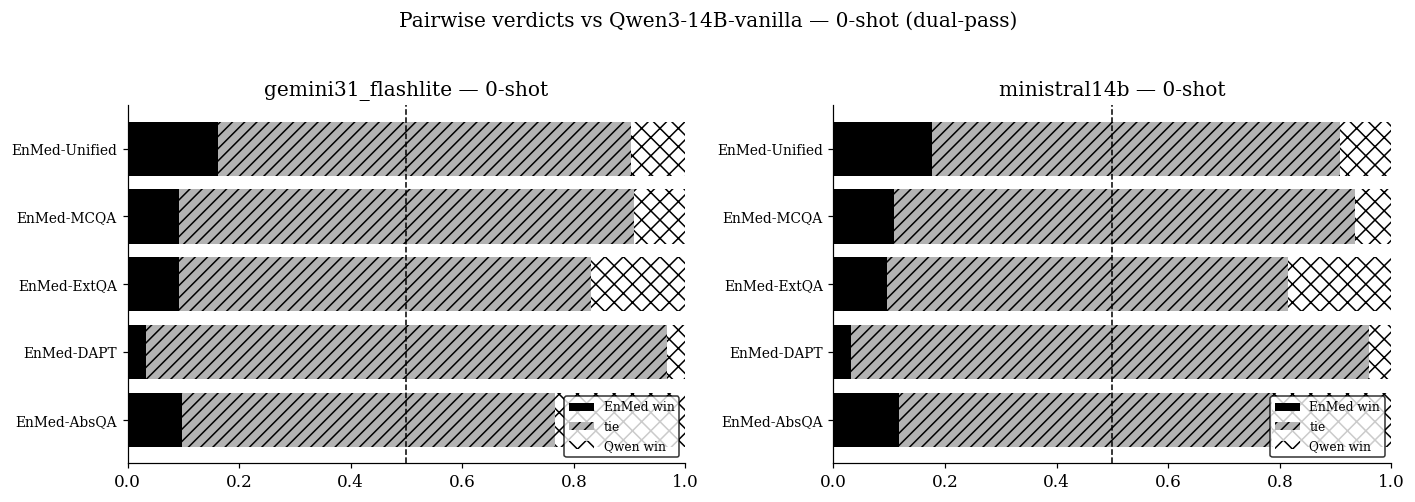

✓ /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/RESULT/figures_stats_paper/fig_pairwise_wtl_shot0.png


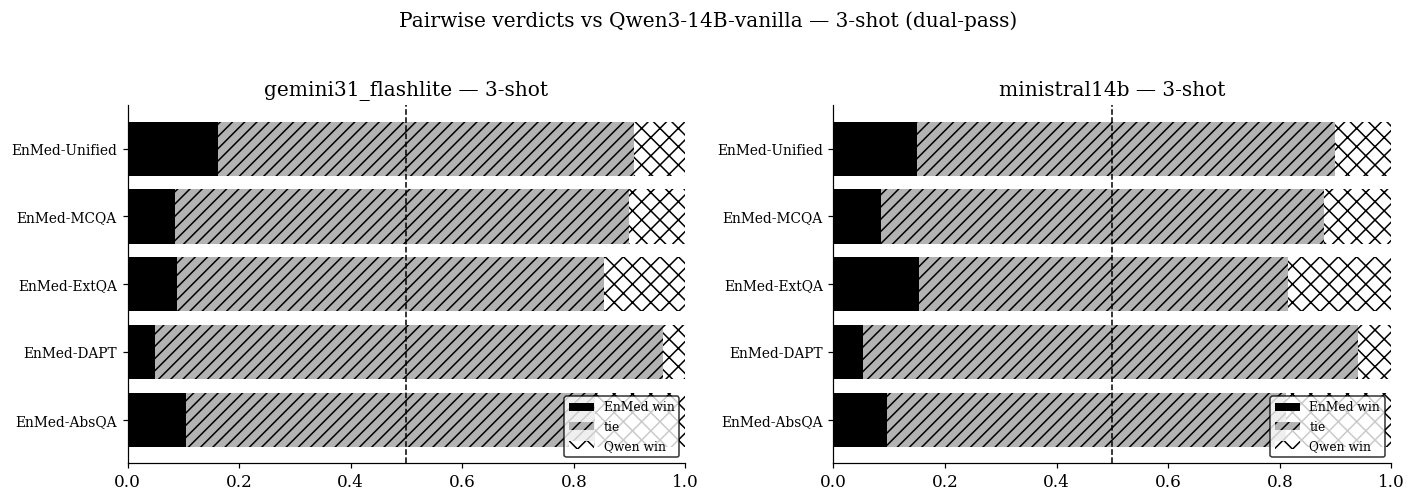

✓ /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/RESULT/figures_stats_paper/fig_pairwise_wtl_shot3.png


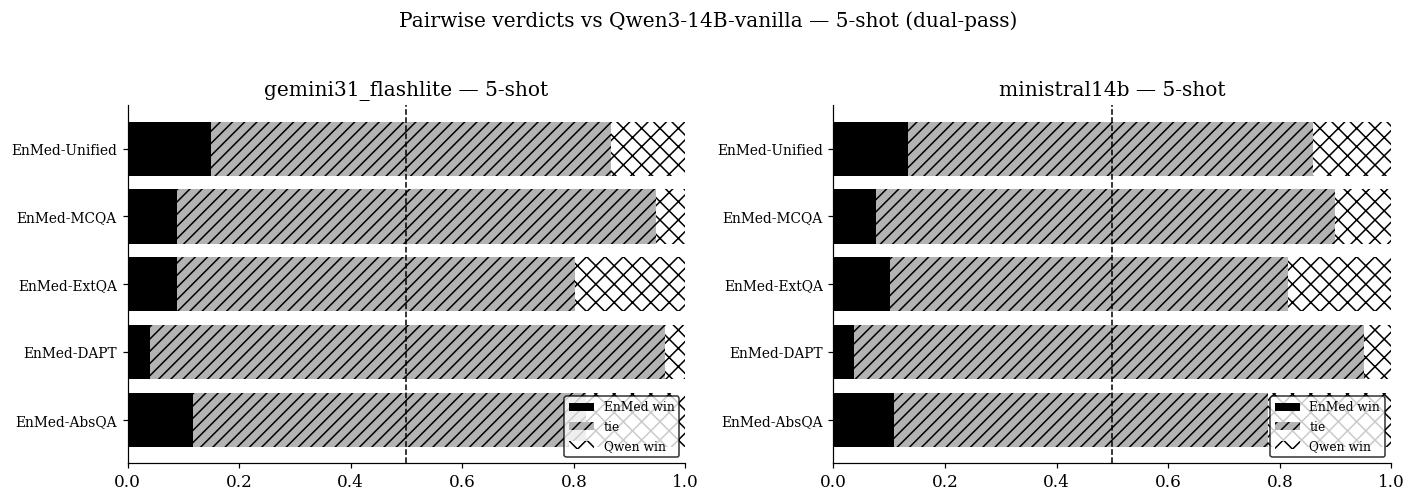

✓ /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/RESULT/figures_stats_paper/fig_pairwise_wtl_shot5.png


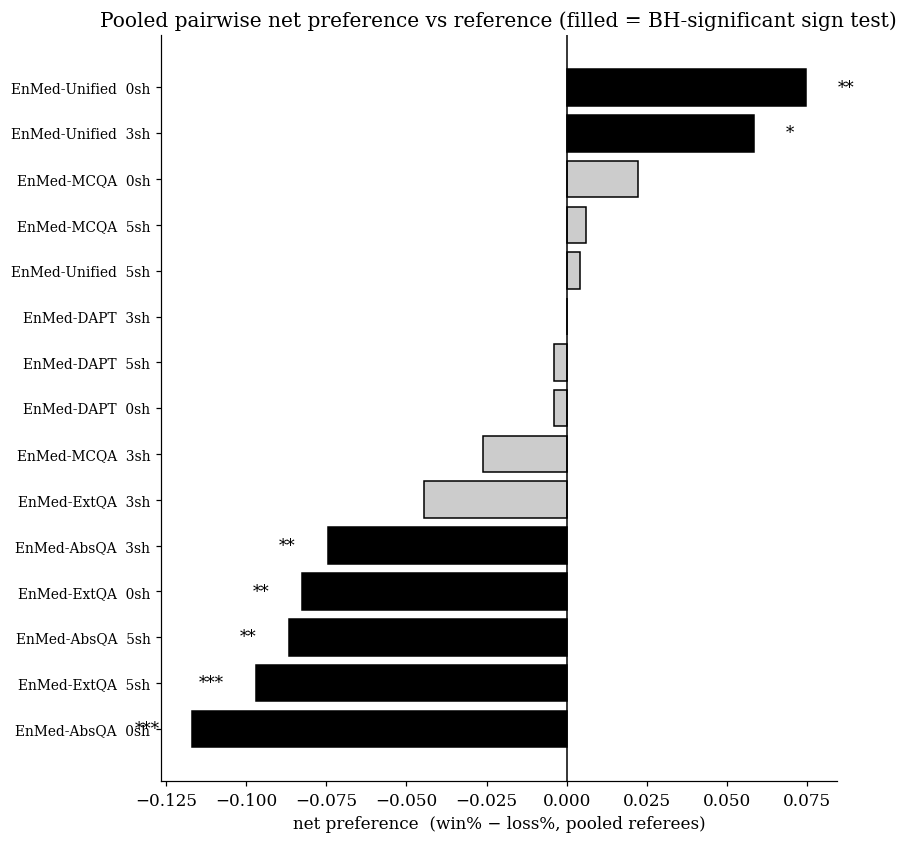

✓ /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/RESULT/figures_stats_paper/fig_pairwise_netpref.png


In [7]:
# Stage 6 — Pairwise figures (per axis, black-on-white)
if df_pair.empty:
    print("Stage 6 skipped: df_pair is empty. Re-run NB9 Stage 4 with the new schema first.")
else:
    AXES_PRESENT = sorted(df_pair["axis"].unique())
    print(f"Building pairwise figures for axes: {AXES_PRESENT}")

    for axis_name in AXES_PRESENT:
        df_axis = df_pair[df_pair["axis"] == axis_name]
        if df_axis.empty: continue

        # (a) stacked W/T/L per referee per shot — one row of subplots per shot
        for s in SHOTS:
            subS = df_axis[df_axis["n_shot"] == s]
            if subS.empty: continue
            refs_this = sorted(subS["referee"].unique())
            if not refs_this: continue
            fig, axes = plt.subplots(1, len(refs_this),
                                     figsize=(6.5*len(refs_this), 4.4), squeeze=False)
            for ax, jn in zip(axes[0], refs_this):
                sub = subS[subS["referee"] == jn]
                if sub.empty: ax.axis("off"); continue
                tot = (sub["wins"]+sub["losses"]+sub["ties"]).replace(0, 1)
                yb = np.arange(len(sub))
                ax.barh(yb, sub["wins"]/tot, color="black", label="challenger win")
                ax.barh(yb, sub["ties"]/tot, left=sub["wins"]/tot, color="0.7",
                        hatch="///", label="tie")
                ax.barh(yb, sub["losses"]/tot, left=(sub["wins"]+sub["ties"])/tot,
                        color="white", edgecolor="black", hatch="xx", label="opponent win")
                ax.axvline(0.5, color="black", lw=1, ls="--")
                labels = [f"{r['challenger']} vs {r['opponent']}" for _, r in sub.iterrows()]
                ax.set_yticks(yb); ax.set_yticklabels(labels, fontsize=8)
                ax.set_xlim(0, 1); ax.set_title(f"{jn} — {s}-shot")
                ax.legend(fontsize=8, loc="lower right")
            fig.suptitle(f"{axis_name} — {s}-shot (dual-pass A/B+B/A)", y=1.03)
            plt.tight_layout()
            out = os.path.join(FIG_DIR, f"fig_pairwise_wtl_{axis_name}_shot{s}.png")
            plt.savefig(out, bbox_inches="tight"); plt.show(); print("✓", out)

    # (b) pooled net-preference forest per axis, with sign-test significance
    if not pool.empty:
        for axis_name in AXES_PRESENT:
            pf = pool[pool["axis"] == axis_name].dropna(subset=["net_pref"]).copy()
            if pf.empty: continue
            pf["label"] = pf["challenger"] + " vs " + pf["opponent"] + \
                          "  " + pf["n_shot"].astype(str) + "sh"
            pf = pf.sort_values("net_pref")
            y = np.arange(len(pf))
            fig, ax = plt.subplots(figsize=(9, 0.42*len(pf)+1.6))
            ax.barh(y, pf["net_pref"],
                    color=["black" if sg else "0.8" for sg in pf["sig_fdr"]],
                    edgecolor="black")
            for yi, (_, r) in zip(y, pf.iterrows()):
                p_fdr = r.get("p_fdr", np.nan)
                mark = stars(p_fdr) if not pd.isna(p_fdr) else ""
                ax.text(r["net_pref"] + (0.01 if r["net_pref"] >= 0 else -0.01), yi,
                        mark, va="center",
                        ha="left" if r["net_pref"] >= 0 else "right", fontsize=11)
            ax.axvline(0, color="black", lw=1)
            ax.set_yticks(y); ax.set_yticklabels(pf["label"], fontsize=9)
            ax.set_xlabel("net preference  (win% − loss%, pooled referees)")
            ax.set_title(f"{axis_name} — pooled pairwise net preference "
                         f"(filled = BH-significant)")
            plt.tight_layout()
            out = os.path.join(FIG_DIR, f"fig_pairwise_netpref_{axis_name}.png")
            plt.savefig(out, bbox_inches="tight"); plt.show(); print("✓", out)


## 🏅 Stage 7 — Rank analysis: Friedman + Nemenyi critical-difference

Across **all systems** on the consensus AbsQA composite, per shot: item-blocked
Friedman test, average ranks, and a Nemenyi critical-difference diagram (paper
Fig. 2 style, monochrome). Systems joined by a bar are not significantly
different at $\alpha=0.05$.

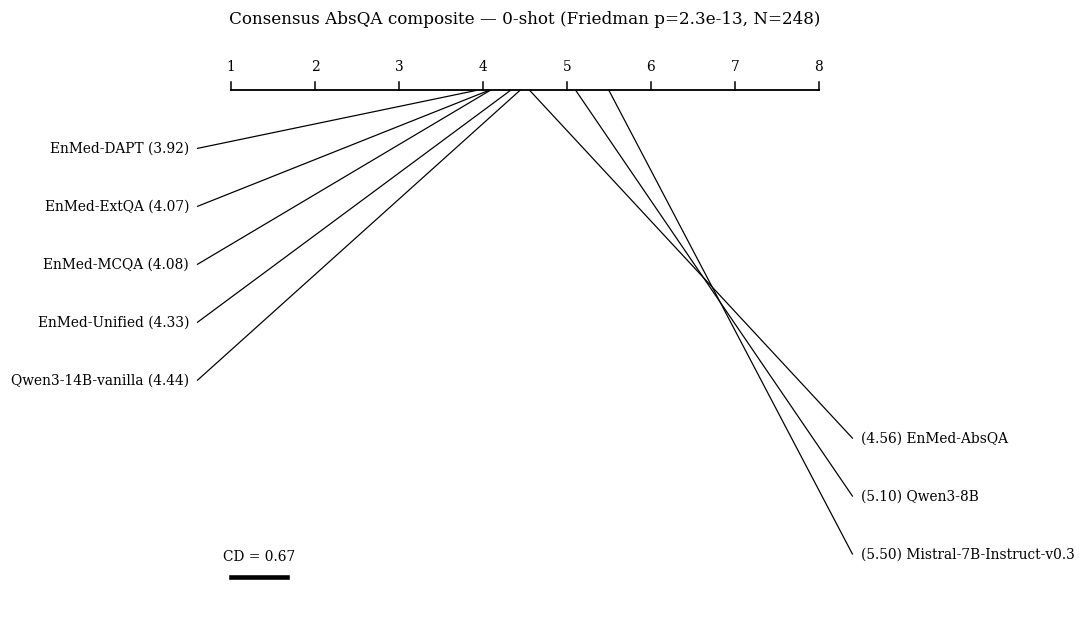

✓ /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/RESULT/figures_stats_paper/fig_cd_shot0.png


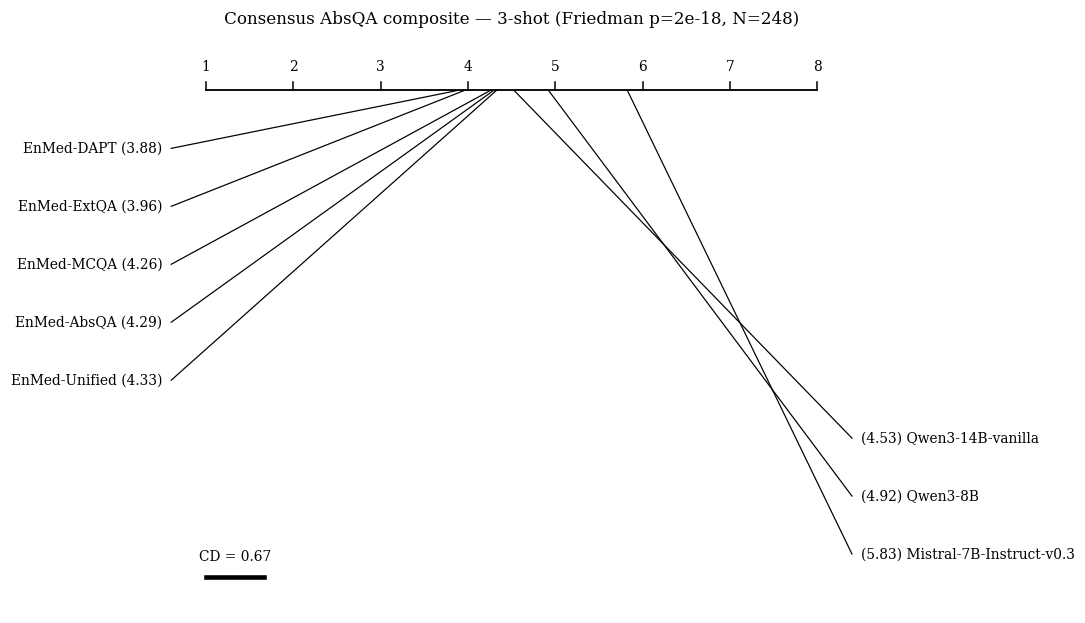

✓ /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/RESULT/figures_stats_paper/fig_cd_shot3.png


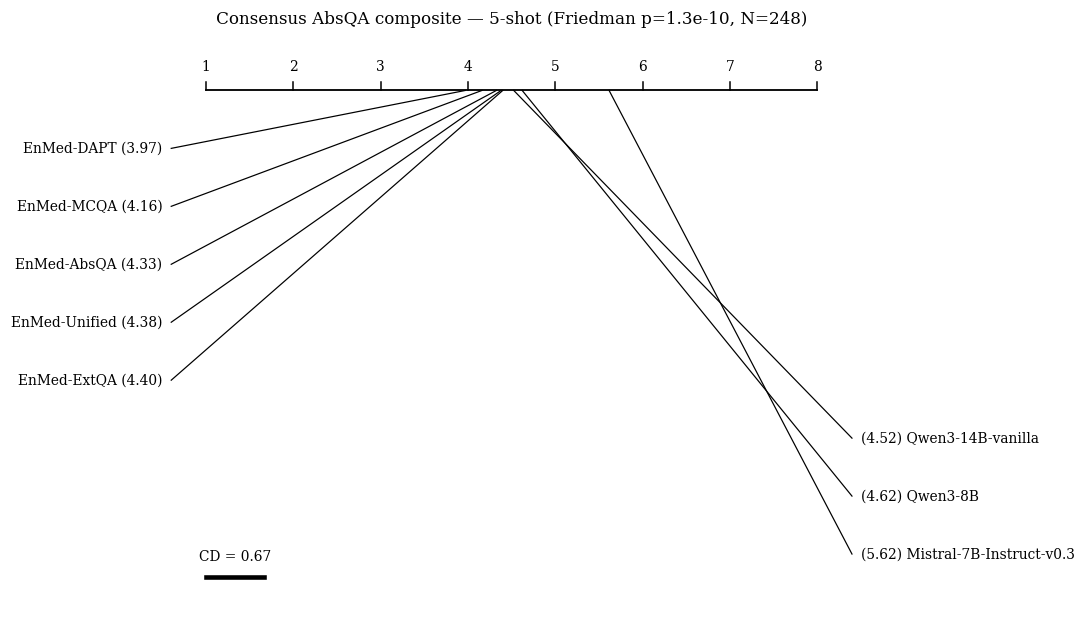

✓ /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/RESULT/figures_stats_paper/fig_cd_shot5.png

✓ rank_analysis.csv


In [8]:
# Stage 7 — Friedman + Nemenyi CD diagram per shot (all systems, consensus composite)
# Nemenyi q_alpha (studentized range / sqrt2) at alpha=0.05
_Q05 = {2:1.960,3:2.343,4:2.569,5:2.728,6:2.850,7:2.949,8:3.031,9:3.102,10:3.164}

def cd_value(k, N):
    q = _Q05.get(k, 3.164)
    return q * np.sqrt(k*(k+1)/(6.0*N))

def draw_cd(avg_rank, cd, title, path):
    order = sorted(avg_rank, key=avg_rank.get)          # best (lowest) first
    ranks = [avg_rank[m] for m in order]
    k = len(order); lo, hi = 1, k
    fig, ax = plt.subplots(figsize=(10, 0.5*k + 1.8))
    ax.set_xlim(lo-0.5, hi+0.5); ax.set_ylim(0, k+2); ax.axis("off")
    ax.plot([lo, hi], [k+1, k+1], color="black", lw=1.2)
    for r in range(lo, hi+1):
        ax.plot([r, r], [k+1, k+1.15], color="black", lw=1)
        ax.text(r, k+1.35, str(r), ha="center", fontsize=9)
    # labels left/right of median rank to avoid overlap
    half = (k+1)/2
    for i, (m, r) in enumerate(zip(order, ranks)):
        yi = k - i
        if r <= half:
            ax.plot([r, lo-0.4], [k+1, yi], color="black", lw=0.8)
            ax.text(lo-0.5, yi, f"{m} ({r:.2f})", ha="right", va="center", fontsize=9)
        else:
            ax.plot([r, hi+0.4], [k+1, yi], color="black", lw=0.8)
            ax.text(hi+0.5, yi, f"({r:.2f}) {m}", ha="left", va="center", fontsize=9)
    # CD bar spanning groups that are not significantly different
    ax.plot([lo, lo+cd], [0.6, 0.6], color="black", lw=3)
    ax.text(lo+cd/2, 0.9, f"CD = {cd:.2f}", ha="center", fontsize=9)
    ax.set_title(title, fontsize=11)
    plt.tight_layout(); plt.savefig(path, bbox_inches="tight"); plt.show()
    print("✓", path)

rank_report = []
for s in SHOTS:
    # items × systems matrix on consensus composite; keep systems with data
    sysmaps = {m: consensus_map(m, s, "composite") for m in MODELS}
    sysmaps = {m: d for m, d in sysmaps.items() if d}
    if len(sysmaps) < 3: continue
    common = set.intersection(*[set(d) for d in sysmaps.values()])
    common = sorted(common)
    if len(common) < 5: continue
    order = sorted(sysmaps.keys())
    M = np.array([[sysmaps[m][i] for m in order] for i in common])   # items × systems
    try:
        fr = stats.friedmanchisquare(*[M[:, j] for j in range(M.shape[1])])
        fried_p = fr.pvalue
    except Exception:
        fried_p = np.nan
    # average ranks (1 = best = highest score → rank descending)
    ranks = (-M).argsort(axis=1).argsort(axis=1) + 1        # per item ranks, 1=best
    avg = {m: float(ranks[:, j].mean()) for j, m in enumerate(order)}
    cd = cd_value(len(order), len(common))
    draw_cd(avg, cd, f"Consensus AbsQA composite — {s}-shot "
            f"(Friedman p={fried_p:.2g}, N={len(common)})",
            os.path.join(FIG_DIR, f"fig_cd_shot{s}.png"))
    for m, r in avg.items():
        rank_report.append({"n_shot": s, "model": m, "avg_rank": r,
                            "friedman_p": fried_p, "CD": cd, "N": len(common)})
df_rank = pd.DataFrame(rank_report)
if not df_rank.empty:
    df_rank.to_csv(os.path.join(OUT_DIR, "rank_analysis.csv"), index=False)
    print("\n✓ rank_analysis.csv")


## 📝 Stage 8 — Significance summary report (auto-written)

In [9]:
# Stage 8 — write the paper-style significance report
L = ["# NB10 — Statistical Analysis (paper-style)", f"_Generated {now_ts()}_", ""]
L.append("## Pointwise item-level paired t-tests (AbsQA composite vs reference)")
for src in SOURCES:
    sub = df_pt[df_pt["source"] == src]
    if sub.empty: continue
    nsig = int(sub["sig_fdr"].sum())
    wins = int(((sub["dz"] > 0) & sub["sig_fdr"]).sum())
    loss = int(((sub["dz"] < 0) & sub["sig_fdr"]).sum())
    L.append(f"- **{src}**: {nsig}/{len(sub)} cells BH-significant "
             f"({wins} wins, {loss} losses). Per-shot detail in "
             f"`pointwise_ttests_by_shot.csv`.")
# per (model, shot) consensus verdict
L.append("\n### Consensus verdict per (candidate × shot)")
csub = df_pt[df_pt["source"] == "consensus"]
tostidx = {(r["model"], r["n_shot"]): r for r in df_tost.to_dict("records")} \
          if not df_tost.empty else {}
poolidx = {(r["challenger"], r["n_shot"]): r for r in pool.to_dict("records")} \
          if not pool.empty else {}
for _, r in csub.sort_values(["model","n_shot"]).iterrows():
    pw = poolidx.get((r["model"], r["n_shot"]))
    tv = tostidx.get((r["model"], r["n_shot"]))
    bits = [f"dz={r['dz']:+.3f} (t={r['t']:+.2f}, p_FDR={r['p_fdr']:.3g})"]
    if pw is not None and pd.notna(pw.get("win_rate")):
        bits.append(f"pooled win-rate={pw['win_rate']:.0%} (p_FDR={pw.get('p_fdr', float('nan')):.3g})")
    pt_sig = bool(r["sig_fdr"]); pw_sig = bool(pw.get("sig_fdr")) if pw is not None else None
    if pt_sig and pw_sig and (r["dz"] > 0) == (pw["win_rate"] > 0.5):
        v = "PREFERRED" if r["dz"] > 0 else "WORSE"
        verdict = f"**{v}** (both paradigms significant, concordant)"
    elif tv is not None and tv.get("equivalent") and not pt_sig:
        verdict = "EQUIVALENT to reference (TOST, ±0.2 SD)"
    elif not pt_sig and (pw_sig is False or pw_sig is None):
        verdict = "no reliable difference"
    else:
        verdict = "MIXED — report conservatively"
    L.append(f"- **{r['model']} @ {int(r['n_shot'])}-shot** — " + "; ".join(bits)
             + f" → {verdict}.")

L.append("\n## Pairwise referees")
if not df_pair.empty:
    nsig = int(df_pair["sig_fdr"].sum())
    L.append(f"- {nsig}/{len(df_pair)} per-referee cells BH-significant by sign test.")
    if not pool.empty:
        psig = int(pool["sig_fdr"].sum())
        L.append(f"- Pooled: {psig}/{len(pool)} (candidate×shot) cells significant. "
                 f"See `pairwise_pooled.csv`.")
L.append("\n## Rank analysis")
if not df_rank.empty:
    for s in SHOTS:
        rs = df_rank[df_rank["n_shot"] == s]
        if rs.empty: continue
        best = rs.loc[rs["avg_rank"].idxmin()]
        L.append(f"- {int(s)}-shot: best avg rank = {best['model']} "
                 f"({best['avg_rank']:.2f}); Friedman p={best['friedman_p']:.2g}; "
                 f"CD={best['CD']:.2f}.")
L.append("\n## Figures (all grayscale, white background)")
L += [f"- `{f}`" for f in sorted(os.listdir(FIG_DIR))]

report = "\n".join(L)
with open(os.path.join(OUT_DIR, "statistical_report.md"), "w", encoding="utf-8") as f:
    f.write(report)
print(report)
print("\n" + "="*60)
print("NB10 COMPLETE")
print("  tables →", OUT_DIR)
print("  figures →", FIG_DIR)


# NB10 — Statistical Analysis (paper-style)
_Generated 2026-07-22_10-37-11_

## Pointwise item-level paired t-tests (AbsQA composite vs reference)
- **gemma4_31b**: 1/15 cells BH-significant (0 wins, 1 losses). Per-shot detail in `pointwise_ttests_by_shot.csv`.
- **gpt54_nano**: 0/15 cells BH-significant (0 wins, 0 losses). Per-shot detail in `pointwise_ttests_by_shot.csv`.
- **consensus**: 1/15 cells BH-significant (0 wins, 1 losses). Per-shot detail in `pointwise_ttests_by_shot.csv`.

### Consensus verdict per (EnMed × shot)
- **EnMed-AbsQA @ 0-shot** — dz=-0.244 (t=-3.84, p_FDR=0.00238); pooled win-rate=32% (p_FDR=0.000104) → **WORSE** (both paradigms significant, concordant).
- **EnMed-AbsQA @ 3-shot** — dz=-0.146 (t=-2.30, p_FDR=0.168); pooled win-rate=36% (p_FDR=0.00497) → MIXED — report conservatively.
- **EnMed-AbsQA @ 5-shot** — dz=-0.126 (t=-1.98, p_FDR=0.209); pooled win-rate=36% (p_FDR=0.00259) → MIXED — report conservatively.
- **EnMed-DAPT @ 0-shot** — dz=+0.012 (t=+0.19,

## Stage 9 — Deep Analysis: Perplexity vs NoPPL
Dedicated matched-pair statistical comparison of the two training pipelines.
Answers: **Is perplexity filtering worth it?**

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Stage 9 — DEEP STATISTICAL ANALYSIS: Perplexity vs NoPPL (matched adapters)
# ═══════════════════════════════════════════════════════════════════════════
# Answers: is PPL filtering worth it? Are the two variants equivalent, or does
# one dominate? Uses matched pairs: Perplexity-<task> vs NoPPL-<task>.
#
# Tests reported per (task adapter × shot × judge):
#   - Paired t-test on consensus composite (per item)
#   - Wilcoxon signed-rank (nonparametric backup)
#   - Cohen's dz effect size + 95% bootstrap CI
#   - TOST equivalence test (±0.2 SD margin)
#   - Pairwise referee sign test on axis C_PPL_vs_NoPPL
# ═══════════════════════════════════════════════════════════════════════════
from scipy import stats as _st

# Match Perplexity-<suffix> to NoPPL-<suffix>
_SUFFIXES = ["DAPT","MCQA","ExtQA","AbsQA","Unified"]
matched_pairs = []
for suf in _SUFFIXES:
    ppl   = f"Perplexity-{suf}"
    noppl = f"NoPPL-{suf}"
    if ppl in MODELS and noppl in MODELS:
        matched_pairs.append((ppl, noppl, suf))
print(f"Matched adapter pairs (PPL, NoPPL): {matched_pairs}")

def _boot_ci(diff, n_boot=2000, alpha=0.05, rng=None):
    rng = rng or np.random.default_rng(42)
    if len(diff) < 3: return (np.nan, np.nan)
    idx = rng.integers(0, len(diff), size=(n_boot, len(diff)))
    means = diff[idx].mean(axis=1)
    return (float(np.quantile(means, alpha/2)), float(np.quantile(means, 1-alpha/2)))

def _tost(a, b, delta_sd=0.2):
    diff = a - b
    if len(diff) < 3: return dict(equivalent=False, p_low=np.nan, p_high=np.nan)
    sd = diff.std(ddof=1)
    if sd == 0: return dict(equivalent=True, p_low=0.0, p_high=0.0)
    margin = delta_sd * sd
    _, p_low  = _st.ttest_1samp(diff, -margin, alternative="greater")
    _, p_high = _st.ttest_1samp(diff, +margin, alternative="less")
    return dict(equivalent=(p_low < 0.05 and p_high < 0.05),
                p_low=float(p_low), p_high=float(p_high))

pn_rows = []      # per (suffix, shot, judge) row
for ppl, noppl, suf in matched_pairs:
    for shot in SHOTS:
        for src in SOURCES:          # SOURCES defined earlier: per-judge names + "consensus"
            if src == "consensus":
                d_p = consensus_map(ppl, shot, "composite")
                d_n = consensus_map(noppl, shot, "composite")
            else:
                d_p = item_axis.get((src, ppl, shot, "composite"), {})
                d_n = item_axis.get((src, noppl, shot, "composite"), {})
            common = sorted(set(d_p) & set(d_n))
            if len(common) < 5: continue
            a = np.array([d_p[r] for r in common])   # Perplexity
            b = np.array([d_n[r] for r in common])   # NoPPL
            diff = a - b
            t_stat, p_t = _st.ttest_rel(a, b)
            try:
                _, p_w = _st.wilcoxon(a, b) if not np.all(diff == 0) else (np.nan, 1.0)
            except ValueError:
                p_w = 1.0
            dz = diff.mean() / (diff.std(ddof=1) + 1e-12)
            ci_lo, ci_hi = _boot_ci(diff)
            tost = _tost(a, b, delta_sd=DELTA_TOST)
            pn_rows.append({
                "suffix": suf, "n_shot": shot, "judge_src": src, "n": len(common),
                "mean_ppl": float(a.mean()), "mean_noppl": float(b.mean()),
                "delta": float(diff.mean()), "delta_ci_low": ci_lo, "delta_ci_high": ci_hi,
                "cohens_dz": float(dz), "p_ttest": float(p_t), "p_wilcoxon": float(p_w),
                "tost_equivalent": tost["equivalent"],
                "tost_p_low": tost["p_low"], "tost_p_high": tost["p_high"],
            })

df_pn = pd.DataFrame(pn_rows)
if not df_pn.empty:
    df_pn["p_primary"] = df_pn["p_wilcoxon"].fillna(df_pn["p_ttest"]).fillna(1.0)
    rej, p_bh, _, _ = multipletests(df_pn["p_primary"], alpha=0.05, method="fdr_bh")
    df_pn["p_fdr"], df_pn["sig_fdr"] = p_bh, rej
    df_pn = df_pn.sort_values(["suffix","n_shot","judge_src"])
    df_pn.to_csv(os.path.join(OUT_DIR, "ppl_vs_noppl_analysis.csv"), index=False)
    print("\n══ Perplexity vs NoPPL — item-level paired tests (per task × shot × judge) ══")
    cols = ["suffix","n_shot","judge_src","n","delta","cohens_dz",
            "delta_ci_low","delta_ci_high","p_ttest","p_wilcoxon","p_fdr","sig_fdr",
            "tost_equivalent"]
    print(df_pn[cols].round(4).to_string(index=False))
else:
    print("No matched PPL/NoPPL items found — check that both variants appear in cache.")

# ─── Pairwise C_PPL_vs_NoPPL headline ─────────────────────────────────────
if not df_pair.empty and "axis" in df_pair.columns:
    dfC = df_pair[df_pair["axis"] == "C_PPL_vs_NoPPL"]
    if not dfC.empty:
        pooledC = dfC.groupby(["challenger","opponent","n_shot"]).agg(
            wins=("wins","sum"), losses=("losses","sum"), ties=("ties","sum")).reset_index()
        pooledC["n_dec"] = pooledC["wins"] + pooledC["losses"]
        pooledC["win_rate"] = pooledC["wins"] / pooledC["n_dec"].replace(0, np.nan)
        pooledC["p_sign"] = [binomtest(int(w), int(n), 0.5).pvalue if n else np.nan
                              for w, n in zip(pooledC["wins"], pooledC["n_dec"])]
        pooledC.to_csv(os.path.join(OUT_DIR, "ppl_vs_noppl_pairwise.csv"), index=False)
        print("\n══ Pairwise referees — C_PPL_vs_NoPPL (pooled across referees) ══")
        print(pooledC.round(3).to_string(index=False))

# ─── Headline figure: Δ (PPL − NoPPL) with 95% bootstrap CI ───────────────
if not df_pn.empty:
    consub = df_pn[df_pn["judge_src"] == "consensus"] if "consensus" in df_pn["judge_src"].values else df_pn
    if not consub.empty:
        consub = consub.copy()
        consub["label"] = consub["suffix"] + " · " + consub["n_shot"].astype(str) + "sh"
        consub = consub.sort_values("delta")
        y = np.arange(len(consub))
        fig, ax = plt.subplots(figsize=(9, 0.42*len(consub)+1.6))
        for i, (_, r) in enumerate(consub.iterrows()):
            ax.plot([r["delta_ci_low"], r["delta_ci_high"]], [i, i],
                    color="black", lw=2)
            ax.plot(r["delta"], i, "o", color="black" if r["sig_fdr"] else "white",
                    markeredgecolor="black", markersize=9)
        ax.axvline(0, color="black", lw=1, ls="--")
        ax.set_yticks(y); ax.set_yticklabels(consub["label"], fontsize=10)
        ax.set_xlabel("Δ composite  (Perplexity − NoPPL, matched items)")
        ax.set_title("Perplexity vs NoPPL — matched-pair mean Δ ± 95% bootstrap CI\n"
                     "(filled = BH-FDR significant)")
        plt.tight_layout()
        out = os.path.join(FIG_DIR, "fig_ppl_vs_noppl_headline.png")
        plt.savefig(out, bbox_inches="tight"); plt.show(); print("✓", out)

# ─── Verdict summary ─────────────────────────────────────────────────────
if not df_pn.empty:
    print("\n══ VERDICT: Is perplexity filtering worth it? ══")
    cs = df_pn[df_pn["judge_src"] == "consensus"] if "consensus" in df_pn["judge_src"].values else df_pn
    for _, r in cs.iterrows():
        if r["sig_fdr"] and r["delta"] > 0:
            v = f"PPL WINS (Δ={r['delta']:+.3f}, dz={r['cohens_dz']:+.2f}, p_FDR={r['p_fdr']:.3g})"
        elif r["sig_fdr"] and r["delta"] < 0:
            v = f"NoPPL WINS (Δ={r['delta']:+.3f}, dz={r['cohens_dz']:+.2f}, p_FDR={r['p_fdr']:.3g})"
        elif r["tost_equivalent"]:
            v = f"EQUIVALENT (TOST ±{DELTA_TOST} SD, Δ={r['delta']:+.3f})"
        else:
            v = f"INCONCLUSIVE (Δ={r['delta']:+.3f}, p_FDR={r['p_fdr']:.3g})"
        print(f"  {r['suffix']:8s}  {int(r['n_shot'])}-shot  →  {v}")
